In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path


In [2]:
data_name = "dayu06"
data = get_data(data_name)
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = False)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)

mid_name = f"{config_find_min_str}"
if config["rsp"]:
    mid_name = f"seed{config["sd"]}"

if config["ns"]>=100000:    
    os.makedirs(f"../../../../pics/{data_name}/{mid_name}/{config_str}", exist_ok=True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

nl = config["nl"] if config["nl"] != None else 1
nl2 = config["nl"] if config["npc"] == 2 else 1
nt = config["nt"] if config["nt"] != None else 1
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))

N50_H100_dc2_dt0.001_ns1000_co0_ndt700_nHMC1_nch5_a1.5_b0.21_dE50_sbt1_ebt3_nt20_ut_sd42_dfs1000
N50_H100_dc2_dt0.001_ns1000_ndt100_nHMC1_a1.5_b0.21_nlsp100_mi10000_gl1e-05_hmc_sd42_bt1_adt1e-05


In [3]:
base_dir = Path.cwd()

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [5]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies_path = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/Emin.npy").resolve()
starting_energies = np.load(starting_energies_path)
starting_points_path = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/samples_min.npy").resolve()
starting_points= np.load(starting_points_path)

idx = np.argsort(starting_energies)
sp_energies_sorted = starting_energies[idx]

if config["rsp"]:
    sp = np.load(base_dir / f"seed{config["sd"]}/starting_points.npy")
elif not find_min_config["hmc"]:
    sp_energies = sp_energies_sorted[:config["nch"]]
    sp = starting_points[idx][:config["nch"], :]
else:
    outdir_startE = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/start_energies.npy").resolve() 
    outdir_start_samples = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/start_samples.npy").resolve() 
    sp_energies_hmc = np.load(outdir_startE)
    sp_hmc = np.load(outdir_start_samples)

    # sp = []
    # sp_energies = []
    np.random.seed(config["sd"])

    flat_E = sp_energies_hmc.flatten()
    flat_samples = sp_hmc.reshape(find_min_config["nlsp"]*find_min_config["ns"], -1)
    # for i in range(config["nch"]):
        # flat_E = sp_energies_hmc[i, :]
        # flat_samples = sp_hmc[i, :, :]

    q25, q75 = np.percentile(flat_E, [25, 75])
    candidate_mask = (flat_E >= q25) & (flat_E <= q75)
    candidate_E = flat_E[candidate_mask]
    candidate_samples = flat_samples[candidate_mask, :]
    indices = np.random.choice(len(candidate_samples), size=config["nch"], replace=False)
    sp = candidate_samples[indices, :]
    sp_energies = candidate_E[indices]
    # sp.append(sp_chain)
    # sp_energies.append(sp_energies_chain)
    # sp = sp_hmc[:config["nch"], -2]
    # sp_energies = sp_energies_hmc[:config["nch"], -2]
    sp= np.array(sp)
    sp_energies= np.array(sp_energies)
    print(sp_energies)

[106.53219023 103.6240983  103.97330028 107.97300882 116.38075524]


In [6]:
sp_mean= np.mean(starting_points, axis = 0)
sp_centered = starting_points-sp_mean

cov = np.cov(sp_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

del sp_hmc, sp_energies_hmc, starting_points, starting_energies
gc.collect()

104

(5, 51)


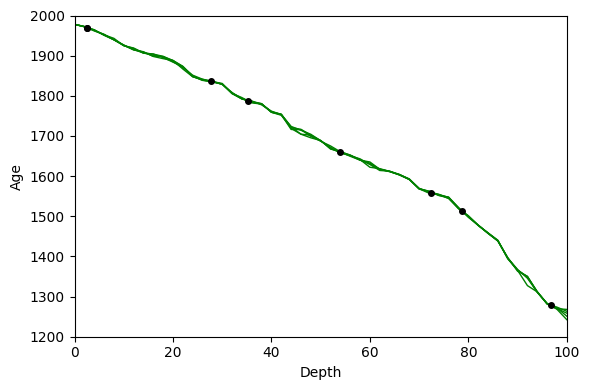

In [7]:
cumulative_sums = np.cumsum(sp[:config["nch"],:], axis=1) * config["dc"]
zeros = np.zeros((*sp[:config["nch"],:].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp[:config["nch"],0])
for j in range(num_samples):
    ax.plot(
        config["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
if config["ns"]>=100000:
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sp_age_depth.jpg")
plt.show()

In [8]:
samples = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/samples.npy").resolve()
samples = np.load(samples)

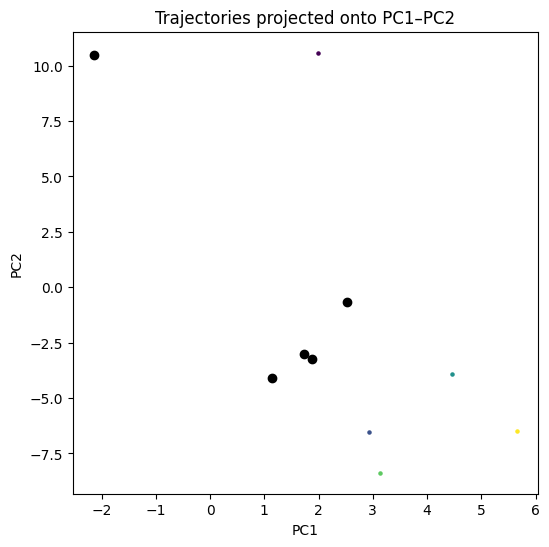

In [9]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain, ::1000, :]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[:,0], coords[:,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[:,0], coords[:,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.scatter(sp @ pc1, sp @ pc2, color = 'black', marker = 'o')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2")
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/trajectory.jpg")
plt.show()

In [10]:
# Print R_hat and N_eff using arviz
ages = data["theta"] - config["dc"] * np.cumsum(samples[:, ::int(len(samples[0, :, 0])/1000), :], axis = 2)
idata = az.convert_to_inference_data(ages)
summary = az.summary(idata, round_to=2)
print(summary)

          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
x[0]   1972.51   0.63  1971.28  1973.67       0.03     0.02    553.98   
x[1]   1962.96   1.06  1961.12  1964.84       0.08     0.03    193.41   
x[2]   1952.83   3.08  1949.68  1960.32       0.46     0.42     96.02   
x[3]   1938.55   3.03  1930.86  1943.39       0.22     0.21    206.03   
x[4]   1926.29   3.90  1917.91  1934.90       0.38     0.41    159.29   
x[5]   1918.10   4.40  1912.76  1926.70       0.40     0.35    150.17   
x[6]   1904.93   4.82  1892.94  1910.22       0.46     0.49    136.73   
x[7]   1898.88   6.66  1887.43  1907.81       1.17     0.99     32.84   
x[8]   1891.29   8.26  1871.25  1905.08       1.87     1.00     18.92   
x[9]   1878.36  13.44  1856.30  1897.70       4.61     0.80     10.09   
x[10]  1864.30  13.43  1844.74  1891.04       4.58     1.39      9.96   
x[11]  1849.74   9.86  1839.21  1872.33       3.63     3.02     12.52   
x[12]  1839.46   1.80  1835.91  1842.61       0.09 

In [11]:
# plt.figure()
# thinned_samples = samples[:, ::int(len(samples[0, :, 0])/1000), :]
# rhats = []
# for i in range(10):
#     ages = data["theta"] - config["dc"] * np.cumsum(thinned_samples[:, i * 1000: (i+1) * 1000, :], axis = 2)
#     idata = az.convert_to_inference_data(ages)
#     summary = az.summary(idata, round_to=10)
#     rhats.append(summary.r_hat)

# rhats = np.array(rhats)
# plt.plot(np.arange(10) * 1000, rhats, '*-')
# if config["ns"]>=100000:    
#     plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/rhat_evolution.jpg")
# plt.show()
    

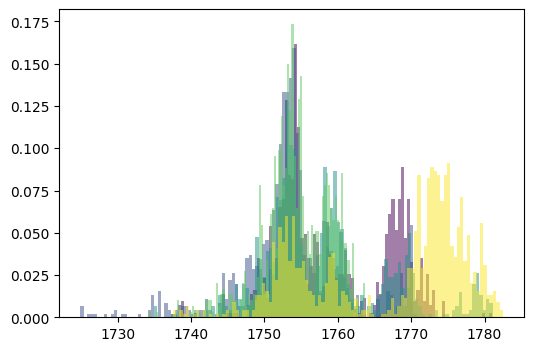

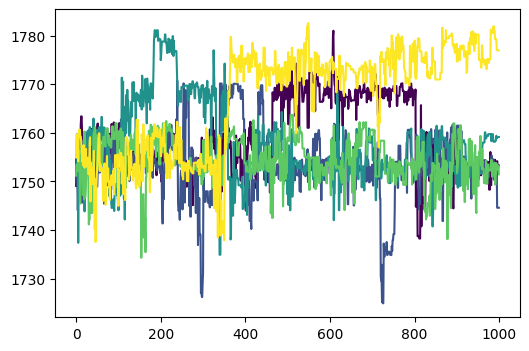

In [12]:
index = 21
interesting_depth = index * config["dc"]
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sampling_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [13]:
bias_values = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/bias.npy").resolve()
bias_values = np.load(bias_values)

In [14]:
# def systematic_resample(weights):
#     N = len(weights)
#     positions = (np.arange(N) + np.random.rand()) / N
#     cumulative_sum = np.cumsum(weights)
#     cumulative_sum /= cumulative_sum[-1] + 1e-15
#     indexes = np.searchsorted(cumulative_sum, positions)
#     return indexes

# resamp_ordered = []
# weights = np.exp(bias_values)

# for i in range(config["nch"]):
#     print(i)
#     chain_weights = weights[i, config["co"]:] / np.sum(weights[:,config["co"]:])
#     resamp_chain = samples[i, systematic_resample(chain_weights), :]
#     resamp_ordered.append(resamp_chain)

# del samples
# gc.collect()

In [15]:
# resamp_ordered = np.array(resamp_ordered)
# print(np.shape(resamp_ordered))

In [16]:
# neff = np.sum(weights, axis = 1)**2 / np.sum(weights**2, axis = (0,1))
# print(f"efficient sample sizes: {neff}")
# # Print R_hat and N_eff using arviz
# ages = data["theta"] - config["dc"] * np.cumsum(resamp_ordered[:, ::1000, :], axis = 2)
# idata = az.convert_to_inference_data(ages)
# summary = az.summary(idata, round_to=2)
# print(summary)

In [17]:
# index = 21
# interesting_depth = index * config["dc"]
# CV_values = data["theta"] - config["dc"] * np.sum(resamp_ordered[:, :, :index], axis = 2)
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(config["nch"]):
#     ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
# # if config["ns"]>=100000:    
# #     plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sampling_along_depth_{interesting_depth}.jpg")
# # plt.show()

# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(config["nch"]):
#     ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
# if config["ns"]>=100000:    
#     plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sampling_along_depth_evolution_{interesting_depth}.jpg")
# plt.show()

In [18]:
# thinned_samples = resamp_ordered[:, ::100, :]
# if config["ns"] >1000000:
#     rhats = []
#     plt.figure()
#     for i in range(int(len(thinned_samples[0, :, 0])/10000 - 1)):  
#         ages = data["theta"] - config["dc"] * np.cumsum(thinned_samples[:, i * 10000: (1+i) * 10000, :], axis = 2)
#         idata = az.convert_to_inference_data(ages)
#         summary = az.summary(idata, round_to=2)
#         rhats.append(summary.r_hat)

#     rhats = np.array(rhats)
#     print(np.shape(rhats))
#     for i in range(len(rhats[0,:])):
#         plt.plot(rhats[:, i], '*-')
#     if config["ns"]>=100000:    
#         plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/rhat_evolution_resamp_with_time.jpg")
#     plt.show()
# del resamp_ordered, thinned_samples
# gc.collect()


In [19]:
energy_values = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/energy.npy").resolve()
energy_values = np.load(energy_values)

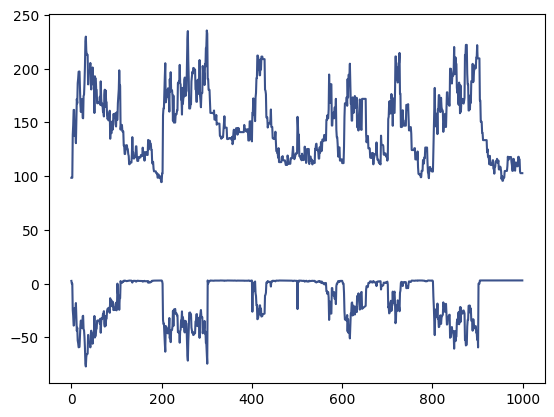

In [20]:
plt.figure()
for i in range(1,2):
    plt.plot(bias_values[i,:1000], color = colors[i])
    plt.plot(energy_values[i,:1000], color = colors[i])
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/bias.jpg")
plt.show()

In [21]:
energy_values = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/energy.npy").resolve()
energy_values = np.load(energy_values)
print(energy_values)

[[100.32075682 125.15501994 138.24617809 ... 109.87116345 109.87116345
  109.87116345]
 [ 98.51414145  98.51414145  98.51414145 ... 102.83812492 102.83812492
  102.83812492]
 [107.97618379 123.21623815 157.7679247  ... 103.76423999 103.76423999
  103.76423999]
 [ 96.19024116 113.47435686 113.47435686 ... 143.67420485 136.10985385
  138.67656747]
 [123.66234012 109.79585165 128.99787813 ... 104.064626   104.064626
  104.064626  ]]


In [22]:
print("Reweighting energies for each temp\n")

if nt > 1 or config["ai"] or config["unb"]:
    factors = np.arange(nt) / (nt - 1)

    if config["ai"]:
        start_temps = (base_dir / f"../../../../output/{data_name}/start_Ts.npy").resolve()
        temp_centers = np.load(start_temps)
        nt = len(temp_centers)
    elif config["unb"]:
        start_temps = (base_dir / f"../../../../output/{data_name}/{mid_name}/temps_sbt{config["sbt"]}_ebt{config["ebt"]}.npy").resolve()
        temp_centers = np.load(start_temps)
        nt = len(temp_centers)
    else:
        temp_centers = config["sbt"] + ((config["ebt"] - config["sbt"]) * factors) if config["ut"] else config["sbt"] * (config["ebt"] / config["sbt"]) ** factors
    temp_colors = plt.cm.viridis(np.linspace(0,1, nt))

    # Compute betas
    betas = 1.0 / temp_centers

    # Initial beta
    beta0 = 1.0
    energy_samples = []
    weights = []
    cutout = config["co"]

    for j in range(nt):
        temp_energy_samples = []
        weights = np.exp(-(betas[j] - beta0) * energy_values + bias_values)
        for i in range(config["nch"]):
            if not config["shb"]:
                weights_i = weights[i, cutout:] / sum(weights[i, cutout:])
            else:
                weights_i = weights[i, cutout:] / sum(weights[:, cutout:])
                weights_i /= sum(weights_i)
            indices = np.random.choice(
                np.arange(cutout, len(weights_i) + cutout),
                size=int(len(weights_i)),
                replace=True,
                p=weights_i,
            )
            print(f"Chain {i} done resampling")
            temp_energy_samples.append(energy_values[i, indices])
        energy_samples.append(temp_energy_samples)
            
    energy_samples = np.array(energy_samples)
    print(np.shape(energy_samples))
    
# del bias_values
# gc.collect()

Reweighting energies for each temp

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chai

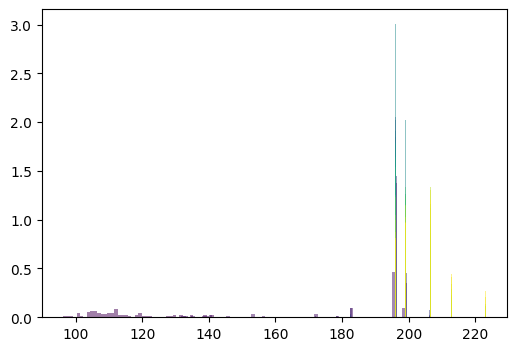

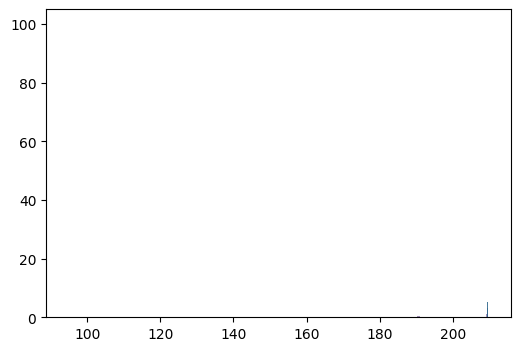

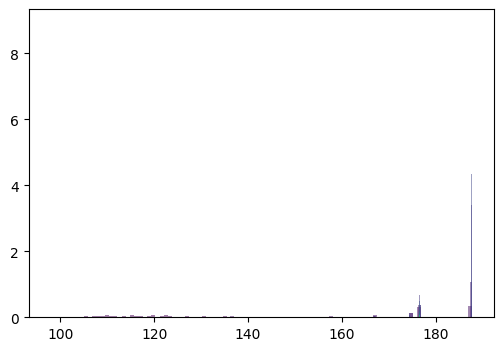

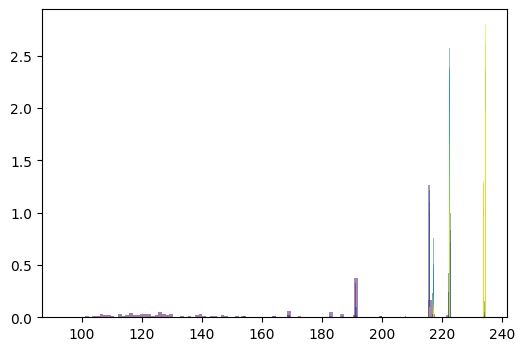

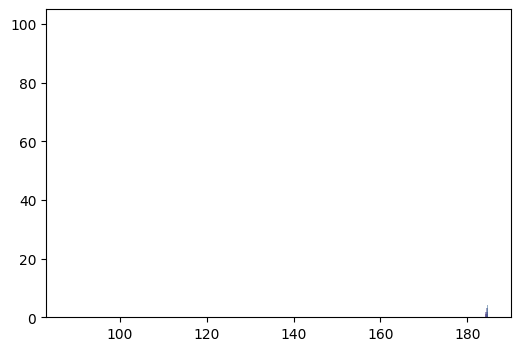

In [23]:
if nt > 1:
    limit_grid = np.linspace(80, 190, 100)
    bin_grid = limit_grid[:-1]
    mean_energies = np.zeros((config["nch"], nt))
    energy_stds = np.zeros((config["nch"], nt))

    for k in range(config["nch"]):
        fig, ax = plt.subplots(figsize=(6, 4))
        for j in range(nt):
            # bin_values = np.zeros_like(bin_grid)
            # weights = np.exp(-(betas[j] - beta0) * energy_values[k, :] + bias_values[k, :])
            # for bin_idx in range(len(bin_grid)):
            #     for i, e in enumerate(energy_values[k, :]):
            #         if e > limit_grid[bin_idx] and e < limit_grid[bin_idx + 1]:
            #             bin_values[bin_idx] += weights[i]
            # print(sum(weights))
            # bin_values /= sum(weights)
            # # print(bin_values)
            # ax.plot(bin_grid + ((190-80)/100), bin_values, color = temp_colors[j])
            ax.hist(energy_samples[j, k, :], bins = 100, color = temp_colors[j], label = f"temp {temp_centers[j]}", alpha = 0.5, density = True)
            mean_energies[k,j]  = np.mean(energy_samples[j,k,:])
            energy_stds[k,j]  = np.std(energy_samples[j, k, :])
        
        # plt.legend()
        if config["ns"]>=100000:    
            plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/temp_pic_chain_{k}.jpg")
        plt.show()

    # del energy_samples
    # gc.collect()

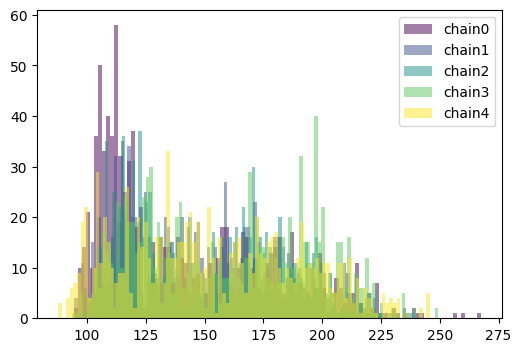

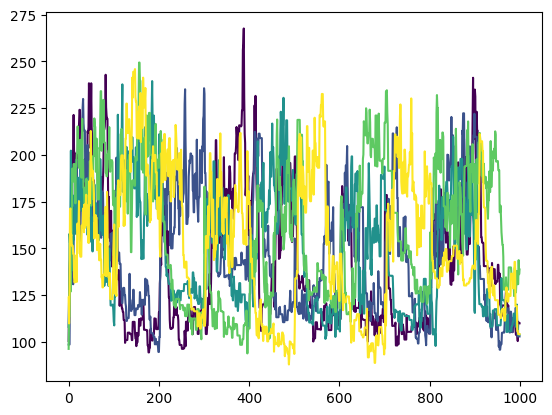

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/temp_energy_hist.jpg")
plt.show()   

plt.figure()
for i in range(config["nch"]):
# i=0
    plt.plot(energy_values[i,:], color = colors[i])
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/energy.jpg")
plt.show()

# del energy_values
# gc.collect()

In [25]:
resampled_samples = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/resamp.npy").resolve()
resampled_samples = np.load(resampled_samples)

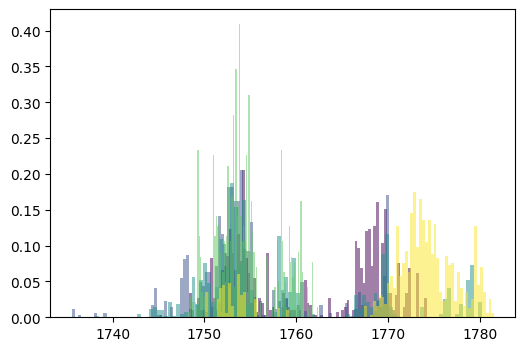

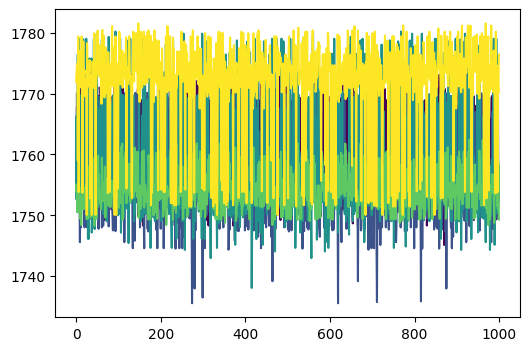

In [26]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/resampling_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}") # Note that this is in fact not a time series so it doesnt make sense to plot it like this.

In [ ]:
resampled_samples = resampled_samples[:,::int(len(resampled_samples[0, :, 0])/10000),:]

In [30]:
# indices = []
# for i in range(len(data["d18O_depths"])):
#     index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
#     indices.append(index)

# plt.figure()
# plt.plot(data["d18O_reference_times"][:], data["d18O_reference"][:])
# for i in range(config["nch"]):
#     variables = resampled_samples[i,:,:]
#     for j in range(len(variables)):
#         d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
#         plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

# plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
# plt.show()

In [31]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])

exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)

[1978.02       1972.096      1962.258      1951.41       1936.43414634
 1923.97       1914.04930233 1906.27714286 1901.55704545 1895.40272727
 1883.95857143 1862.55046512 1845.85166667 1838.68975    1834.33076923
 1823.83809524 1803.35863636 1789.65090909 1784.04933333 1779.5925
 1776.94       1769.5375     1745.61772727 1718.385      1699.91416667
 1681.92145833 1667.11833333 1658.56574468 1649.098      1639.58658537
 1627.81090909 1615.61591837 1609.18714286 1601.58428571 1587.02489796
 1567.30904762 1557.46682927 1551.43341463 1537.25181818 1515.54886364
 1495.64       1473.85538462 1456.0016     1434.3796     1392.4425
 1365.32       1343.782      1308.754      1281.475      1267.18928571
 1252.90357143]


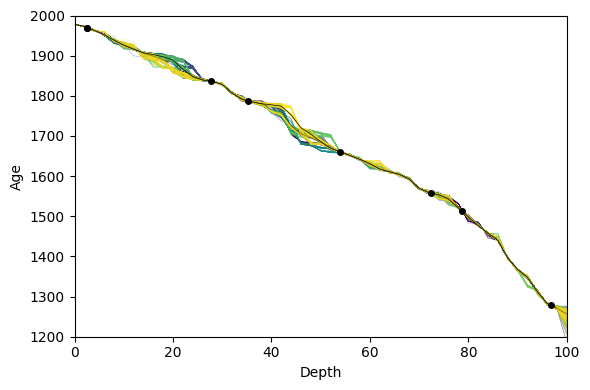

In [32]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
if config["ns"]>=100000:
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/age_depth.jpg")
plt.show()

# del resampled_samples
# gc.collect()

In [33]:
if (nt > 1 or nl > 1):
    base_dir = Path.cwd()

    files = [(base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/deltaF_chain{i}.bin").resolve() for i in range(config["nch"])]

    stride = 1
    deltaF = []

    for f in files:
        print(f)
        dF_data = np.fromfile(f, dtype=np.float64)
        print(np.shape(dF_data))
        # reshape to full dimensions first
        first_dim = int(config["ns"]/stride) if int(config["ns"]/stride) != 0 else 1
        dF_data = dF_data.reshape(first_dim, nl, nl2, nt)
        # take every 10th element along the first axis
        deltaF.append(dF_data)

    deltaF = np.array(deltaF)
    print(deltaF.shape)

C:\Users\hanna\Desktop\PhD\Bacon\output\dayu06\N50_H100_dc2_dt0.001_ns1000_ndt100_nHMC1_a1.5_b0.21_nlsp100_mi10000_gl1e-05_hmc_sd42_bt1_adt1e-05\N50_H100_dc2_dt0.001_ns1000_co0_ndt700_nHMC1_nch5_a1.5_b0.21_dE50_sbt1_ebt3_nt20_ut_sd42_dfs1000\deltaF_chain0.bin
(20000,)
C:\Users\hanna\Desktop\PhD\Bacon\output\dayu06\N50_H100_dc2_dt0.001_ns1000_ndt100_nHMC1_a1.5_b0.21_nlsp100_mi10000_gl1e-05_hmc_sd42_bt1_adt1e-05\N50_H100_dc2_dt0.001_ns1000_co0_ndt700_nHMC1_nch5_a1.5_b0.21_dE50_sbt1_ebt3_nt20_ut_sd42_dfs1000\deltaF_chain1.bin
(20000,)
C:\Users\hanna\Desktop\PhD\Bacon\output\dayu06\N50_H100_dc2_dt0.001_ns1000_ndt100_nHMC1_a1.5_b0.21_nlsp100_mi10000_gl1e-05_hmc_sd42_bt1_adt1e-05\N50_H100_dc2_dt0.001_ns1000_co0_ndt700_nHMC1_nch5_a1.5_b0.21_dE50_sbt1_ebt3_nt20_ut_sd42_dfs1000\deltaF_chain2.bin
(20000,)
C:\Users\hanna\Desktop\PhD\Bacon\output\dayu06\N50_H100_dc2_dt0.001_ns1000_ndt100_nHMC1_a1.5_b0.21_nlsp100_mi10000_gl1e-05_hmc_sd42_bt1_adt1e-05\N50_H100_dc2_dt0.001_ns1000_co0_ndt700_nHMC1_nch

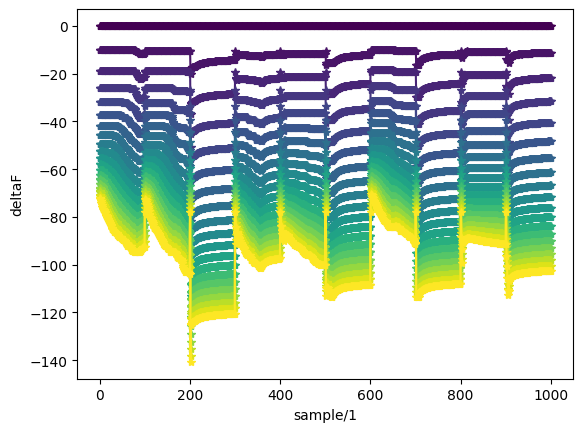

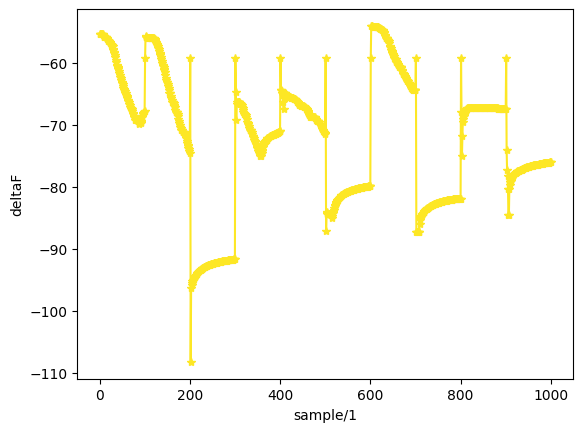

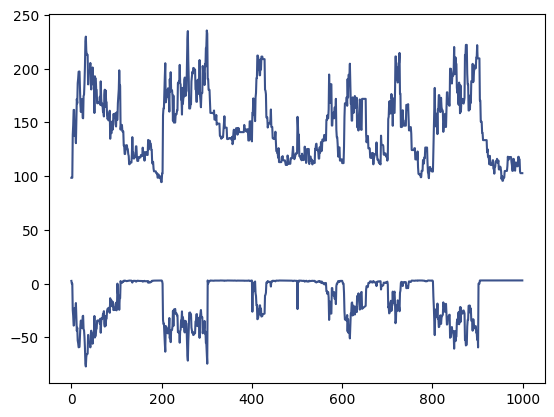

[ 0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]


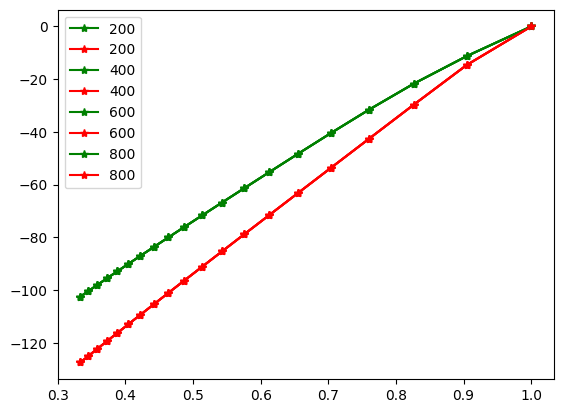

In [34]:
%matplotlib inline
if (nt > 1 or nl > 1):
    if (not (config["npc"] == None)):

        if config["npc"] == 2:
            xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
            ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

            X, Y = np.meshgrid(xcoords, ycoords)

            for i in range(config["nch"]):
                last_delta_F = np.squeeze(deltaF[i, -1, :, :, 9])
                indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
                plt.figure(figsize=(6,5))
                pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
                plt.colorbar(pcm, label='Value')
                plt.xlabel('X coordinate')
                plt.ylabel('Y coordinate')
                plt.title('2D Plot with coordinates')
                if config["ns"]>=100000:    
                    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/last_deltaF.jpg")
                plt.show()
        if config["npc"] == 1:
            xcoords = np.linspace(config["sb"], config["eb"], config["nl"])

            fig, ax = plt.subplots()

            lines = []

            for j in range(nt):
                line, = ax.plot([], [], lw=2, label=f"T{j}", color = temp_colors[j])
                lines.append(line)
            ax.set_xlim(config["sb"], config["eb"])
            ax.set_ylim(np.min(deltaF), np.max(deltaF))

            ax.set_xlabel("s")
            ax.set_ylabel("delta_F")

            def update(frame):
                i = frame
                for j in range(nt):
                    sample_delta_F = np.squeeze(deltaF[0, i, :, 0, j])
                    lines[j].set_data(xcoords, sample_delta_F)
                ax.set_title(f"sample i={i}")
                return lines,
        
            frames = int(config["ns"]/stride)  # number of frames
            ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=100, repeat = False)
            if config["ns"]>=100000:    
                ani.save(f"../../../../pics/{data_name}/{mid_name}/{config_str}/deltaF_animation.gif", writer="pillow", fps=5)

            plt.show()
    elif nt>1 and nl == 1 and nl2 == 1 and config["ns"] > stride:
        fig, ax = plt.subplots()

        x = np.linspace(0, int(config["ns"]/stride), int(config["ns"]/stride))
        for k in range(nt):
            sample_delta_F = np.squeeze(deltaF[2, :, 0, 0, k])
            ax.plot(x, sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")

        # plt.legend()
        plt.xlabel(f"sample/{stride}")
        plt.ylabel("deltaF")
        if config["ns"]>=100000:    
            plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/deltaF.jpg")
        plt.show()

        fig, ax = plt.subplots()

        sample_delta_F = np.squeeze(deltaF[2, :, 0, 0, int(config["nt"]/2)])
        ax.plot(x, sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")

        # plt.legend()
        plt.xlabel(f"sample/{stride}")
        plt.ylabel("deltaF")
        if config["ns"]>=100000:    
            plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/deltaF_last.jpg")
        plt.show()

        plt.figure()
        for i in range(1,2):
            plt.plot(bias_values[i,:], color = colors[i])
            plt.plot(energy_values[i,:], color = colors[i])
            sample_delta_F = np.squeeze(deltaF[i, :, 0, 0, int(config["nt"]/2)])
            # plt.plot(x, sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")
        if config["ns"]>=100000:    
            plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/energy_bias_df.jpg")
        plt.show()

        # deltaF_other = np.fromfile(r"C:\Users\hanna\Desktop\PhD\Bacon\output\dayu06\N50_H100_dc2_dt0.001_ns1000_ndt100_nHMC1_a1.5_b0.21_nlsp100_mi10000_gl1e-05_hmc_sd37_bt1_adt1e-05\N50_H100_dc2_dt0.001_ns1250000_co10_ndt800_nHMC1_nch5_a1.5_b0.21_dE50_sbt1_ebt3_nt20_ut_sd37_shb\deltaF.bin", dtype = np.float64)
        # first_dim = int(1250000/stride) if int(1250000/stride) != 0 else 1
        # deltaF_other = deltaF_other.reshape(1, first_dim, nl, nl2, nt)
        plt.figure()
        # print(np.shape(deltaF_other))
        print(deltaF[0, ::100, 0,0,0])
        for i in range(1,5):
            plt.plot(betas, deltaF[2, -1, 0, 0, :], label = f"{int(i * config["ns"] / (5 * stride))}", marker = '*', color = "green")
            plt.plot(betas, deltaF[0, -1, 0, 0, :], label = f"{int(i * config["ns"] / (5 * stride))}", marker = '*', color = "red")
            # plt.plot(betas, deltaF_other[0, int(i * 1250000 / 500), 0, 0, :], label = f"{int(i * 1250000 / 500)}", marker = '*', color = "green")
        plt.legend()
        plt.show()

In [35]:
# print(mean_energies)
# print(energy_stds)
# min_std = np.min(energy_stds)
# N = int(1 + (np.max(mean_energies)- np.min(mean_energies))/min_std)
# print(N)
# mean_mean_energies = np.mean(mean_energies, axis = 0)
# mean_energy_stds = np.mean(energy_stds, axis = 0)
# energies = [mean_mean_energies[0]]
# Ts = [1]

# plt.figure()
# plt.plot(temp_centers, mean_energy_stds)
# plt.plot(temp_centers, mean_energy_stds, '*')
# plt.show()

# for i in range(1, N):
#     energies.append(energies[i-1] + min_std)
#     idx = np.searchsorted(mean_mean_energies, energies[i-1], side = "right")
#     print(idx)
#     if idx < len(temp_centers):
#         T_diff = temp_centers[idx] - temp_centers[idx-1]
#         Ts.append(Ts[i-1] + ((min_std * Ts[i-1]**2)/((mean_energy_stds[idx-1] + (Ts[i-1] - temp_centers[idx - 1]) * (mean_energy_stds[idx] - mean_energy_stds[idx - 1])/T_diff)**2)))
#     elif idx == len(temp_centers):
#         T_diff = temp_centers[idx-1] - temp_centers[idx-2]
#         Ts.append(Ts[i-1] + ((min_std * Ts[i-1]**2)/((mean_energy_stds[idx-1] + (Ts[i-1] - temp_centers[idx - 1]) * (mean_energy_stds[idx - 1] - mean_energy_stds[idx - 2])/T_diff)**2)))

# # outdir_Ts = base_dir / "../../../../output/{data_name}/{config_find_min_str}"/f"start_Ts.npy"
# # np.save(outdir_Ts, Ts)
# print(Ts)
# print(len(Ts)) # Try running with this!